# Hyperparameter Tuning for Regression Models

This notebook explores how different hyperparameters affect the performance of regression models. Our main goal is to predict car "best buy" scores and body performance metrics by comparing Decision Trees, Random Forests, and Support Vector Regression (SVR).

# Code Setup

## Uploaded Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

## The DATA

In [2]:
body = pd.read_csv("../Datasets/Hyperparameter1/bodyPerformance.csv")
cars = pd.read_csv('../Datasets/Hyperparameter1/Dataset.csv')

print(body.head())
print(cars.head())

    age gender  height_cm  weight_kg  body fat_%  diastolic  systolic  \
0  27.0      M      172.3      75.24        21.3       80.0     130.0   
1  25.0      M      165.0      55.80        15.7       77.0     126.0   
2  31.0      M      179.6      78.00        20.1       92.0     152.0   
3  32.0      M      174.5      71.10        18.4       76.0     147.0   
4  28.0      M      173.8      67.70        17.1       70.0     127.0   

   gripForce  sit and bend forward_cm  sit-ups counts  broad jump_cm class  
0       54.9                     18.4            60.0          217.0     C  
1       36.4                     16.3            53.0          229.0     A  
2       44.8                     12.0            49.0          181.0     C  
3       41.4                     15.2            53.0          219.0     B  
4       43.5                     27.1            45.0          217.0     B  
   Unnamed: 0  Id  year          brand  \
0           0   0  2016          Honda   
1           1  

## Data Preparation

To make the data usable for machine learning, I need to convert categorical text (like gender or car brand) into numbers. I'll use LabelEncoder for the classification target and get_dummies for the regression features to handle these strings.

In [3]:
df_class = body.copy()

le_gender = LabelEncoder()
df_class['gender'] = le_gender.fit_transform(df_class['gender'])

le_class = LabelEncoder()
df_class['class'] = le_class.fit_transform(df_class['class'])

X_class = df_class.drop('class', axis=1)
y_class = df_class['class']

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42
)

In [4]:
df_reg = cars.copy()

df_reg = df_reg.drop(columns=['Unnamed: 0', 'Id'])

df_reg = pd.get_dummies(df_reg, drop_first=True)

df_reg = df_reg.replace([np.inf, -np.inf], np.nan)
df_reg = df_reg.dropna()

y_reg = df_reg['best_buy1']
X_reg = df_reg.drop('best_buy1', axis=1)

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

## Decision Tree Regressor: Analyzing Depth
The first model I’m testing is the Decision Tree. I want to see how the "depth" (how many levels the tree has) impacts its ability to generalize.

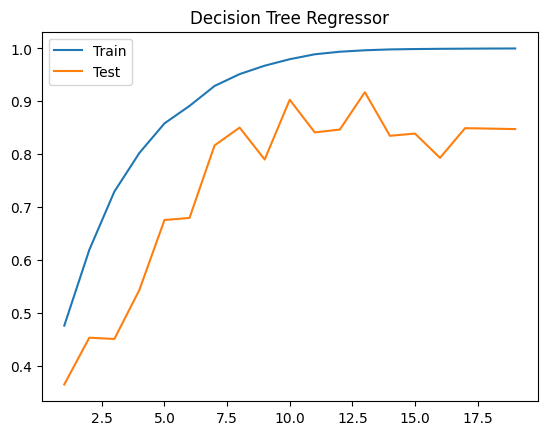

In [5]:
depths = range(1, 20)
train_scores = []
test_scores = []

for d in depths:
    model = DecisionTreeRegressor(max_depth=d)
    model.fit(Xr_train, yr_train)
    train_scores.append(model.score(Xr_train, yr_train))
    test_scores.append(model.score(Xr_test, yr_test))

plt.plot(depths, train_scores, label="Train")
plt.plot(depths, test_scores, label="Test")
plt.legend()
plt.title("Decision Tree Regressor")
plt.show()

### Plot Analysis

The Trend: As the depth increases, the "Train" score climbs toward a perfect 1.0. However, the "Test" score peaks early and then becomes very unstable.
Why this happens: A tree that is too deep starts "memorizing" the training data (overfitting).
Conclusion: The sweet spot is around a depth of 9. Beyond that, the model becomes too complex and performance on new data (Test) starts to fluctuate wildly.


## Random Forest: Strength in Numbers
Next, I’ll look at a Random Forest. Instead of one tree, I’m using an ensemble. I’m testing how many trees (n_estimators) we need for the best result.

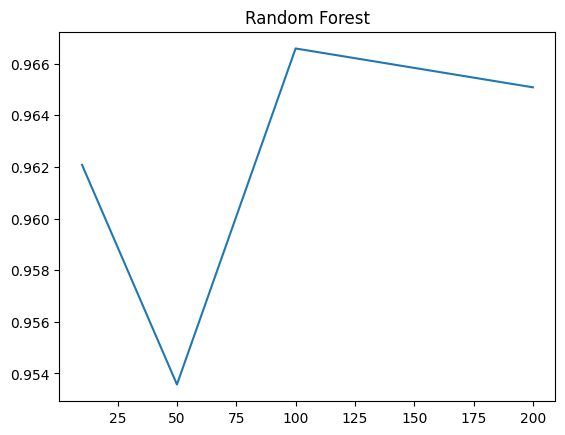

In [6]:
trees = [10, 50, 100, 200]
scores = []

for t in trees:
    model = RandomForestRegressor(n_estimators=t)
    model.fit(Xr_train, yr_train)
    scores.append(model.score(Xr_test, yr_test))

plt.plot(trees, scores)
plt.title("Random Forest")
plt.show()

### Plot Analysis
The Trend: There is a massive jump in accuracy when moving from 10 to 50 trees. After 100 trees, the improvement levels off.
Why this happens: More trees reduce the variance and "smooth out" the errors of individual trees, but there are diminishing returns after a certain point.
Conclusion: 100 trees provide a high level of accuracy (over 0.96) without wasting extra computing power.

## Support Vector Regression (SVR): Complexity Control
Finally, I’ll test SVR. Here, I am tuning the C parameter, which controls the penalty for errors.

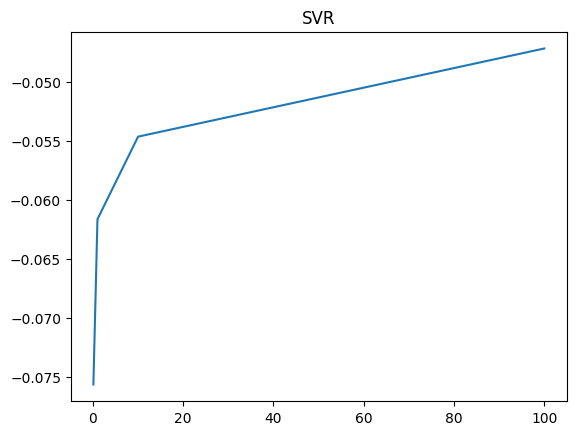

In [7]:
C_values = [0.1, 1, 10, 100]
scores = []

for c in C_values:
    model = SVR(C=c)
    model.fit(Xr_train, yr_train)
    scores.append(model.score(Xr_test, yr_test))

plt.plot(C_values, scores)
plt.title("SVR")
plt.show()

### Plot Analysis
The Trend: The R-squared scores are actually negative, though they improve slightly as C increases.
Why this happens: A negative score means the model is performing worse than a horizontal line representing the mean of the data. This suggests that the SVR, with its current settings, is a very poor fit for this specific car dataset.
Conclusion: SVR is not suitable for this data without significant feature scaling or a different kernel choice.

# Final Project Conclusion

After analyzing all three models, here are my findings:

- Winner: The Random Forest Regressor is the clear winner, achieving a test score of roughly 0.96. It is robust and handles the dataset's complexity much better than a single tree.
- Runner Up: The Decision Tree performs well at moderate depths (~0.85), but it is too prone to overfitting to be the primary choice.
- Worst Performer: The SVR failed to find any meaningful patterns in this dataset, resulting in negative performance scores.

Recommendation: For future predictions on this car dataset, I will use a Random Forest with 100 estimators for the most reliable results.